# FFS w skrócie: FWHM klatki

Najprostsze użycie `pyaraucaria.ffs.FFS`, takie jak w **ofp** (`fits_proc/tools/astro_tools.py`, `fwhm_exec`)
i w **TOI** (`fits_gui.py`): jedna metoda `calc_frame_fwhm()` liczy statystyki klatki, znajduje gwiazdy
i podaje medianowe FWHM, eliptyczność i wskaźniki ostrości.

> **Uwaga przed produkcją:** `calc_frame_fwhm()` woła teraz `find_lines()`, które na pełnej klatce
> 4096×4108 (jk15c) potrzebuje ok. 13 GB pamięci. Do czasu binowania w FFS nie puszczać tej wersji
> na klatki 4k. Klatki 2048² (zb08, wk06) liczą się w ok. 5 s.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))   # pyaraucaria z tego repozytorium, nie z instalacji w kernelu
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from pyaraucaria.ffs import FFS
import pyaraucaria
print("pyaraucaria z:", os.path.dirname(pyaraucaria.__file__))

DATA = os.path.expanduser("~/work/data/fits_examples")
# kolory masek: stala kolejnosc (niebieski, pomaranczowy, morski, zolty)
C1, C2, C3, C4 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"


def show(ax, img, title="", lo=1, hi=99.5, cmap="gray"):
    """Obraz w skali percentyli lo..hi."""
    vmin, vmax = np.nanpercentile(img, [lo, hi])
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, origin="lower", interpolation="nearest")
    ax.set_title(title)


def overlay(ax, mask, color, label):
    """Polprzezroczysta maska jednego koloru (z etykieta do legendy)."""
    rgba = np.zeros(mask.shape + (4,))
    rgba[mask] = list(int(color[i:i + 2], 16) / 255 for i in (1, 3, 5)) + [0.8]
    ax.imshow(rgba, origin="lower", interpolation="nearest")
    ax.plot([], [], "s", color=color, label=f"{label} ({int(mask.sum())} px)")


pyaraucaria z: /Users/mgorski/work/src/pyaraucaria/pyaraucaria


## 1. Klatka i jedno wywołanie

In [2]:
image = fits.getdata(os.path.join(DATA, "zb08c_0612_72902.fits"))

ffs = FFS(image)
ffs.saturation = 60000          # ADU; ofp i TOI ustawiaja to z konfiguracji teleskopu
ffs.calc_frame_fwhm(N_stars=50) # domyslnie threshold=10 (w sigmach tla), fwhm=10, box=10, clip=4

frame = ffs.stats["frame"]
for key in ("fwhm", "fwhm_x", "fwhm_y", "ellipticity", "theta_spread", "cpe", "shape", "ci"):
    print(f"{key:13s} {frame[key]:8.3f}   {ffs.stats_description['frame'][key]}")

fwhm             3.888   Median of the full width at half maximum (FWHM) of the brightest sources in the frame
fwhm_x           3.915   Median FWHM measured along the X axis
fwhm_y           4.002   Median FWHM measured along the Y axis
ellipticity      0.101   Median source ellipticity (1 − b/a), describing PSF elongation
theta_spread     0.449   Axial (period pi) circular spread of source position angles, in radians. Low spread with high ellipticity indicates a common elongation direction (e.g. tracking or wind)
cpe              0.052   Median central pixel excess (CPE) of detected sources; higher values indicate sharper, more centrally concentrated profiles
shape            0.795   Median PSF shape parameter defined as CPE × FWHM^2 
ci               0.905   Median concentration index (CI) of detected stars in the frame; 


Wartości są medianami z gwiazd zmierzonych w `star_info()`, po odrzuceniu odstających (`clip`).
Gdy gwiazd jest za mało, pola mają wartość `NaN`. ofp zamienia je wtedy na `None`.

## 2. Co zostało zmierzone

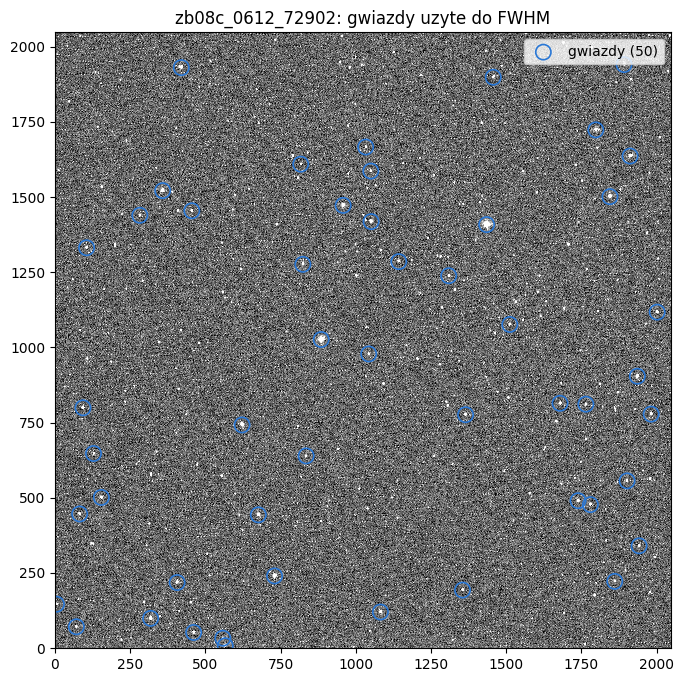

x,y,max_adu,fwhm,ellipticity,cpe,ci
int64,int64,uint16,float64,float64,float64,float64
1435,1408,32615,3.929293552831965,0.1134764900328592,0.05234907815238166,0.911057727519079
885,1026,17212,4.479191151900041,0.14838154042439333,0.04101655908079015,0.9470512477826647
622,742,5718,3.4921287146156135,0.10898604236415654,0.0651470110363586,0.8829312102529249
730,240,5707,3.82518171538792,0.11236862777410017,0.051251636901937715,0.909981045633352
358,1521,5183,4.01577064884296,0.050517647267123045,0.04811135554262151,0.9303105553192121
318,99,4249,3.6517936640630237,0.028614041409076196,0.05955743523903029,0.9129822542547392
958,1472,4155,4.312034388840518,0.06096323852001351,0.04090899423637253,0.940633006942451
676,443,3695,3.624346774487239,0.0667328626643291,0.062007135669197695,0.8928891571995683
1051,1418,2373,3.7806738504134505,0.06875698598882796,0.05648175939316216,0.9018436984039626


In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
show(ax, ffs.image, "zb08c_0612_72902: gwiazdy uzyte do FWHM")
ax.scatter(ffs.coo[:, 1], ffs.coo[:, 0], s=120, facecolors="none", edgecolors=C1, linewidths=1.2,
           label=f"gwiazdy ({len(ffs.coo)})")
if ffs.masks["lines"].any():
    overlay(ax, ffs.masks["lines"], C2, "linie")
ax.legend(loc="upper right")
plt.show()

ffs.stars["x", "y", "max_adu", "fwhm", "ellipticity", "cpe", "ci"][:10]

## 3. Co robi `calc_frame_fwhm()`

```python
self.mk_saturation_mask()    # piksele >= self.saturation -> masks["saturation"]
self.mk_stats()              # statystyki klatki (bez zlych pikseli)
self.sky_map()               # mapa tla -> maps["sky"]
self.mk_threshold_mask()     # piksele ponad tlem -> masks["threshold"]
self.find_lines()            # satelity -> masks["lines"]
self.find_stars(threshold, fwhm)   # kandydaci ponad mapa tla, poza zlymi pikselami
self.star_info(box, N_stars) # pomiar N_stars najjasniejszych (bez nasyconych i zlych pikseli w wycinku)
self.calc_star_stats(clip)   # mediany -> stats["frame"]
```

Wszystkie maski z `ffs.exclude` są pomijane w statystykach, tle i detekcji. Pełny przebieg krok po kroku
pokazuje `ffs_full.ipynb`.

## 4. Tak jak w ofp: kolejne liczby gwiazd

In [4]:
def fwhm_exec(array, saturation, stars_no=(10, 50, 100, 500)):
    """Odpowiednik AstroTools.fwhm_exec z ofp."""
    ffs = FFS(image=array)
    ffs.saturation = saturation
    for n in stars_no:
        ffs.calc_frame_fwhm(N_stars=n)
        out = {k: (None if np.isnan(ffs.stats["frame"][k]) else round(float(ffs.stats["frame"][k]), 2))
               for k in ("fwhm_x", "fwhm_y", "fwhm", "ellipticity")}
        if out["fwhm_x"] is not None or out["fwhm_y"] is not None:
            return n, out
    return None, None


fwhm_exec(image, saturation=60000)

(10, {'fwhm_x': 3.88, 'fwhm_y': 3.79, 'fwhm': 3.88, 'ellipticity': 0.09})